# Practica 2 - Ejercicio 1:
* Considere una población de individuos que no se reproducen, y que evolucionan en tiempo discreto. 
A cada paso de tiempo cada uno de ellos
puede morir con probabilidad d. Calcule numéricamente la distribución
de probabilidad de la población en función del tiempo (para algunos
tiempos, y para un par de valores de d). Compare con la distribución
binomial exacta

---

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator

In [2]:
def distribucion_binomial(n, p, N):
    """Función que devuelve la distribucion binomial
    Args:
        n (int): Número de ensayos
        p (float): Probabilidad de éxito
        size (int): Tamaño de la muestra
    Returns:
        float : Distribución binomial
    """
    return math.comb(N, n) * (p ** n) * ((1 - p) ** (N - n))

In [3]:
def evolucion_poblacion(n0, d, tf):
    """Función que devuelve la evolución de una población
    Args:
        n0 (int): Numero de individuos a timpo 0
        d (float): Tasa de supervivencia de cada individuo
        tf (int): Tiempo final de la simulacion
    Returns:
        poblacion (np.array): Numero de individuos en cada tiempo
    """

    poblacion = np.zeros(tf)
    n = np.ones(n0) # Estado de la población
    poblacion[0] = n0
    for i in range(1,tf):
        for j in range(len(n)):
            # Cada individuo tiene una probabilidad d de morir
            estado = np.random.choice([1, 0], p=[1-d, d])
            n[j] = estado
        poblacion[i] = n.sum()
    
    return poblacion

* Parámetros de la simulación

In [18]:
n0 = 100 # Número de individuos a tiempo 0
d = 0.9 # Tasa de supervivencia
tf = 10 # Tiempo final de la simulación

In [19]:
muestreo = 1000
dist_bin = np.zeros(muestreo)
for i,n in enumerate(np.linspace(0, n0, muestreo, dtype=int)):
    dist_bin[i] = distribucion_binomial(n, 1-d, n0)

In [20]:
ensemble_poblaciones = np.zeros((1000, tf))
for i in range(1000):
    ensemble_poblaciones[i,:] = evolucion_poblacion(n0, d, tf)

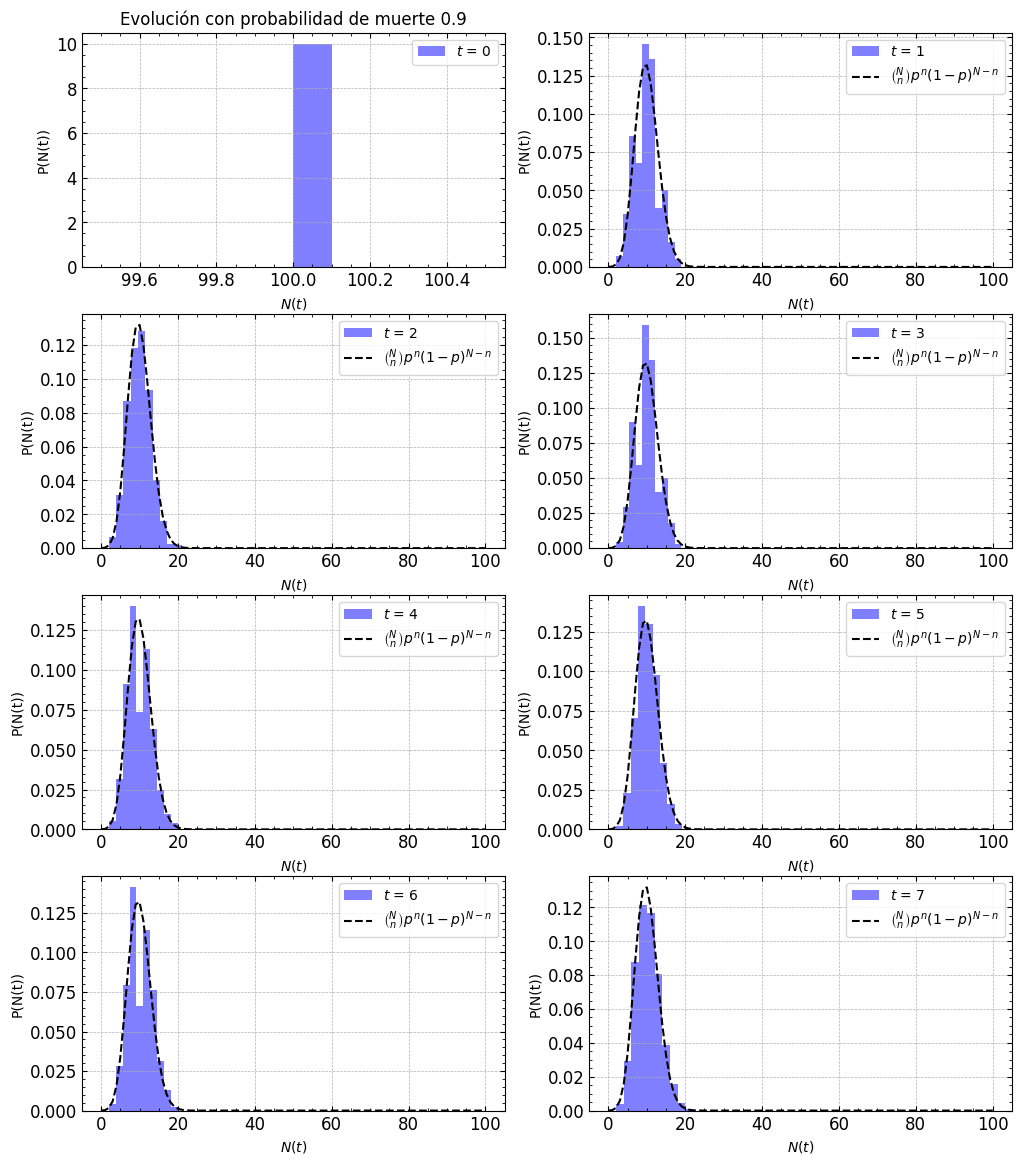

In [21]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(12, 14))
for i in range(0,tf-2):
    ix = i//2
    iy = i%2
    if ix == 0 and iy == 0:
        ax[ix,iy].set_title(f'Evolución con probabilidad de muerte {d}')
        ax[ix,iy].hist(ensemble_poblaciones[:,i], density=True, alpha=0.5, label=f'$t$ = {i}', color = 'blue')
    else:
        ax[ix,iy].hist(ensemble_poblaciones[:,i], density=True, alpha=0.5, label=f'$t$ = {i}', color = 'blue')
        ax[ix,iy].plot(np.linspace(0, n0, muestreo, dtype=int), dist_bin, label=r'$\binom{N}{n}p^{n}(1-p)^{N-n}$', color='black', linestyle='--')
    ax[ix,iy].set_xlabel('$N(t)$')
    ax[ix,iy].set_ylabel('P(N(t))')
    ax[ix,iy].xaxis.set_minor_locator(AutoMinorLocator())
    ax[ix,iy].yaxis.set_minor_locator(AutoMinorLocator())
    ax[ix,iy].yaxis.set_ticks_position('both')
    ax[ix,iy].xaxis.set_ticks_position('both')
    ax[ix,iy].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    ax[ix,iy].legend(fontsize=10, loc = "best")
    ax[ix,iy].grid(linestyle='--', linewidth=0.5)

plt.savefig(f'EvolucionProb_{d}.pdf')
plt.show()